In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
folder = "data/dataset/UTKFace"

rows = []
for f in os.listdir(folder):
    if not f.endswith(".jpg"):
        continue
    parts = f.split("_")
    if len(parts) < 3:
        continue
    try:
        age, gender, race = int(parts[0]), int(parts[1]), int(parts[2])
    except ValueError:
        continue
    if 0 <= age <= 116:
        rows.append({"age": age, "gender": gender, "race": race})

df = pd.DataFrame(rows)
print(f"Total images: {len(df)}")
df

Total images: 23705


,age,gender,race
0,100,0,0
1,100,0,0
2,100,1,0
3,100,1,0
4,100,1,0
...,...,...,...
23700,9,1,3
23701,9,1,3
23702,9,1,4
23703,9,1,4


In [4]:
print(df["age"].describe())
print("\nImages with age <= 3:", (df["age"] <= 3).sum())
print("Images with age > 3:", (df["age"] > 3).sum())

count    23705.000000
mean        33.300907
std         19.885708
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64

Images with age <= 3: 1894
Images with age > 3: 21811


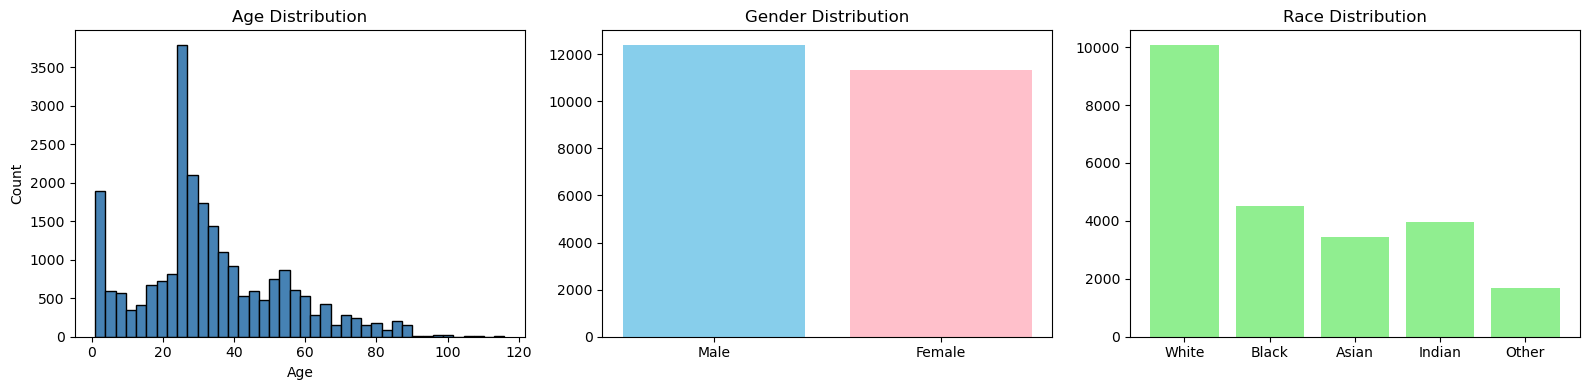

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["age"], bins=40, color="steelblue", edgecolor="black")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

g = df["gender"].value_counts().reindex([0, 1], fill_value=0)
axes[1].bar(["Male", "Female"], g.values, color=["skyblue", "pink"])
axes[1].set_title("Gender Distribution")

race_names = ["White", "Black", "Asian", "Indian", "Other"]
r = df["race"].value_counts().reindex(range(5), fill_value=0)
axes[2].bar(race_names, r.values, color="lightgreen")
axes[2].set_title("Race Distribution")

plt.tight_layout()
plt.show()